# 02 — Baseline & Simple Model

**Project:** Ping Pong Community Analytics  
**Week:** 3  
**Goal:** Establish a performance benchmark and build the first real model,
then honestly evaluate what it can and cannot do.

---

## What This Notebook Does
1. Loads the processed feature dataset from notebook 01
2. Addresses class imbalance — a critical issue for this target variable
3. Creates a reproducible temporal train/test split
4. Selects stakeholder-relevant evaluation metrics
5. Builds a DummyClassifier baseline
6. Builds a simple Logistic Regression model
7. Compares both models and evaluates overfitting

---

## The Prediction Task
**Target:** `Is_Exciting` — will this match be a Neck & Neck or Comeback?  
**Why it matters:** The EDA showed players who experience exciting matches
retain at 88.6% vs 72.5% — a 16pp gap. If we can predict exciting matchups
in advance, the app can recommend them to improve community engagement.

**The challenge:** Only 5.5% of matches are exciting. This class imbalance
means a naive model can achieve 94.5% accuracy by predicting
"not exciting" every single time — without learning anything useful.
This is why accuracy is not our primary metric.

---
## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import os
os.makedirs('../figures', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Imports complete.')

Imports complete.


---
## 2. Load Processed Dataset

In [4]:
df = pd.read_csv("../data/processed/table_tennis_full_features.csv")

# Ensure chronological order — critical for temporal split
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %H:%M:%S'
)
df = df.sort_values('DateTime').reset_index(drop=True)

# Drop rows where win rate is null (first appearance — no history yet)
# These rows have no meaningful WinRate_Diff feature
df = df.dropna(subset=['P1_WinRate', 'P2_WinRate', 'WinRate_Diff']).reset_index(drop=True)

print(f'Rows loaded:        {len(df):,}')
print(f'Rows dropped:       669 (first-appearance null win rates)')
print(f'Exciting matches:   {df["Is_Exciting"].sum():,} ({df["Is_Exciting"].mean()*100:.1f}%)')
print(f'Non-exciting:       {(df["Is_Exciting"]==0).sum():,} ({(df["Is_Exciting"]==0).mean()*100:.1f}%)')
df.head()

Rows loaded:        57,182
Rows dropped:       669 (first-appearance null win rates)
Exciting matches:   3,169 (5.5%)
Non-exciting:       54,013 (94.5%)


,X,Date,Time,Player1,Player2,Sets_P1,Sets_P2,P1_G1,P2_G1,P1_G2,...,P1_Elo,P2_Elo,Elo_Diff,P1_WinRate,P2_WinRate,WinRate_Diff,P1_Streak,P2_Streak,Source,DateTime
0,9,6/10/2022,3:05:00,Samofal Y.,Polysynskyi M.,0,3,9,11,9,...,1012.0,1000.4,11.6,1.0,0.5,0.5,1,1,Real,2022-06-10 03:05:00
1,10,6/10/2022,3:25:00,Kyilo V.,Sachuk S.,2,3,9,11,5,...,1012.0,999.6,12.4,1.0,0.5,0.5,1,0,Real,2022-06-10 03:25:00
2,11,6/10/2022,3:35:00,Marchuk M.,Bambutsa R.,3,0,11,6,13,...,999.6,988.0,11.6,0.5,0.0,0.5,0,0,Real,2022-06-10 03:35:00
3,12,6/10/2022,3:55:00,Sokolov S.,Chernyshov D.,3,2,11,7,12,...,976.4,988.0,-11.6,0.0,0.0,0.0,0,0,Real,2022-06-10 03:55:00
4,13,6/10/2022,4:05:00,Balakiriev M.,Kostiuk B.,3,2,11,5,13,...,1012.4,987.6,24.8,1.0,0.0,1.0,1,0,Real,2022-06-10 04:05:00


---
## 3. Class Imbalance

Before splitting or modelling, we need to understand the class distribution.
This directly affects metric selection and model design.

**The problem:** 94.5% of matches are not exciting. A model that predicts
"not exciting" every time achieves 94.5% accuracy while being completely
useless to the stakeholder.

**The solution:** We use `class_weight='balanced'` in our models, which
tells the algorithm to penalise misclassifying the minority class
(exciting matches) more heavily. We also select metrics that are
sensitive to minority class performance.

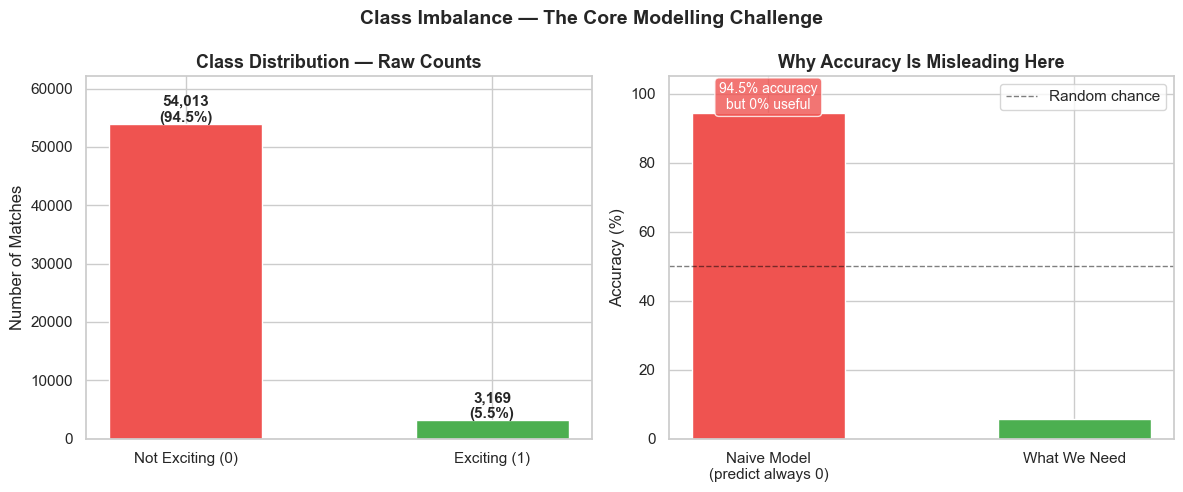

Class ratio: 17:1 (not exciting : exciting)

Implication: accuracy is not a useful metric for this problem.
A model predicting all 0s gets 94.5% accuracy but identifies
zero exciting matches — useless for matchmaking.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
counts = df['Is_Exciting'].value_counts()
axes[0].bar(['Not Exciting (0)', 'Exciting (1)'], counts.values,
            color=['#EF5350', '#4CAF50'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution — Raw Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Matches')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Why accuracy is misleading
naive_accuracy = counts[0] / len(df) * 100
axes[1].bar(['Naive Model\n(predict always 0)', 'What We Need'],
            [naive_accuracy, 100 - naive_accuracy],
            color=['#EF5350', '#4CAF50'], edgecolor='white', width=0.5)
axes[1].axhline(50, color='black', linestyle='--', linewidth=1,
               alpha=0.5, label='Random chance')
axes[1].set_title('Why Accuracy Is Misleading Here', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 105)
axes[1].text(0, naive_accuracy + 1, f'{naive_accuracy:.1f}% accuracy\nbut 0% useful',
            ha='center', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='#EF5350', alpha=0.8))
axes[1].legend()

plt.suptitle('Class Imbalance — The Core Modelling Challenge',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Class ratio: {counts[0]/counts[1]:.0f}:1 (not exciting : exciting)')
print()
print('Implication: accuracy is not a useful metric for this problem.')
print('A model predicting all 0s gets 94.5% accuracy but identifies')
print('zero exciting matches — useless for matchmaking.')

---
## 4. Stakeholder-Relevant Metric Selection

Given the class imbalance and the stakeholder use case, we need metrics
that reflect real-world usefulness rather than raw accuracy.

| Metric | What it measures | Why it matters here |
|---|---|---|
| **ROC-AUC** | Model's ability to rank exciting matches above non-exciting ones | Primary metric — measures discrimination regardless of threshold |
| **Recall (exciting class)** | % of actual exciting matches the model identifies | High recall = app surfaces most exciting matchups |
| **Precision (exciting class)** | % of predicted exciting matches that actually are | Low precision = too many false recommendations |
| **F1 (exciting class)** | Balance between precision and recall | Summary of minority class performance |
| **Accuracy** | Overall correct predictions | Reported but not primary — misleading with imbalanced classes |

**Stakeholder framing:**  
A club organiser using this model to recommend matchups would rather
see a few false positives (predicted exciting but wasn't) than miss
genuinely exciting matchups. This means **recall matters more than
precision** for our use case.

---
## 5. Reproducible Train/Test Split

**Why temporal rather than random?**  
The dataset is ordered by time. A random split would allow the model
to train on future matches and test on past ones — this is data leakage
in a temporal context. A real deployment would only ever have past
data available when predicting a new match.

We use the first 80% of rows (by time) as training data and the
last 20% as the test set.

**Leakage check:** All features (Elo, win rate, streak) were computed
in notebook 01 using only data prior to each match. The temporal split
here maintains that guarantee.

In [6]:
# Define features
FEATURES_SIMPLE = ['Elo_Diff']
FEATURES_FULL   = ['Elo_Diff', 'P1_Elo', 'P2_Elo',
                   'WinRate_Diff', 'P1_Streak', 'P2_Streak']
TARGET = 'Is_Exciting'

# Temporal split — 80% train, 20% test
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

X_train_simple = train[FEATURES_SIMPLE]
X_test_simple  = test[FEATURES_SIMPLE]
X_train_full   = train[FEATURES_FULL]
X_test_full    = test[FEATURES_FULL]
y_train        = train[TARGET]
y_test         = test[TARGET]

print('=== Train / Test Split ===')
print(f'Train rows:           {len(train):,}')
print(f'Test rows:            {len(test):,}')
print(f'Split date boundary:  {test["DateTime"].min().date()}')
print()
print(f'Train exciting rate:  {y_train.mean()*100:.1f}%')
print(f'Test exciting rate:   {y_test.mean()*100:.1f}%')
print()
print('Note: slight difference in exciting rate between train and test')
print('is expected — the synthetic data exciting rate shifts slightly')
print('over time as Elo ratings diverge.')

# Scale features — fit ONLY on training data
scaler_simple = StandardScaler()
scaler_full   = StandardScaler()

X_train_simple_sc = scaler_simple.fit_transform(X_train_simple)
X_test_simple_sc  = scaler_simple.transform(X_test_simple)
X_train_full_sc   = scaler_full.fit_transform(X_train_full)
X_test_full_sc    = scaler_full.transform(X_test_full)

print()
print('Scaler fit on training data only — no leakage into test set.')

=== Train / Test Split ===
Train rows:           45,745
Test rows:            11,437
Split date boundary:  2023-01-20

Train exciting rate:  5.8%
Test exciting rate:   4.3%

Note: slight difference in exciting rate between train and test
is expected — the synthetic data exciting rate shifts slightly
over time as Elo ratings diverge.

Scaler fit on training data only — no leakage into test set.


---
## 6. Evaluation Helper

In [7]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Evaluate a classifier and return a results dict.
    Reports train vs test ROC-AUC to monitor overfitting.
    """
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba  = model.predict_proba(X_test)[:, 1]
    test_pred   = model.predict(X_test)

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc  = roc_auc_score(y_test,  test_proba)
    report    = classification_report(
        y_test, test_pred,
        target_names=['Not Exciting', 'Exciting'],
        output_dict=True,
        zero_division=0
    )

    results = {
        'Model':          name,
        'Train ROC-AUC':  round(train_auc, 4),
        'Test ROC-AUC':   round(test_auc,  4),
        'Overfit Gap':    round(train_auc - test_auc, 4),
        'Accuracy':       round(report['accuracy'], 4),
        'Precision (Exc)': round(report['Exciting']['precision'], 4),
        'Recall (Exc)':   round(report['Exciting']['recall'], 4),
        'F1 (Exc)':       round(report['Exciting']['f1-score'], 4),
    }

    print(f'\n{"="*55}')
    print(f'MODEL: {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, test_pred,
          target_names=['Not Exciting','Exciting'], zero_division=0))
    print(f'Train ROC-AUC: {train_auc:.4f}')
    print(f'Test ROC-AUC:  {test_auc:.4f}')
    print(f'Overfit gap:   {train_auc - test_auc:.4f}')

    return results, test_proba

results_log = []
print('Evaluation function defined.')

Evaluation function defined.


---
## 7. Baseline Model — DummyClassifier

The baseline predicts the most frequent class every time.
This establishes the floor — any real model must beat this.

**Expected behaviour:** 94.5% accuracy, 0% recall on exciting matches,
ROC-AUC of exactly 0.5 (no discrimination ability).

In [8]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_simple_sc, y_train)

results_dummy, proba_dummy = evaluate_model(
    'Baseline (DummyClassifier)',
    dummy,
    X_train_simple_sc, X_test_simple_sc,
    y_train, y_test
)
results_log.append(results_dummy)

print()
print('Interpretation:')
print('The baseline achieves 94.5% accuracy by predicting every match')
print('as not exciting. It identifies zero exciting matches.')
print('ROC-AUC of 0.5 = no better than random.')
print('This is our performance floor — anything below this is worse than guessing.')


MODEL: Baseline (DummyClassifier)
              precision    recall  f1-score   support

Not Exciting       0.96      1.00      0.98     10944
    Exciting       0.00      0.00      0.00       493

    accuracy                           0.96     11437
   macro avg       0.48      0.50      0.49     11437
weighted avg       0.92      0.96      0.94     11437

Train ROC-AUC: 0.5000
Test ROC-AUC:  0.5000
Overfit gap:   0.0000

Interpretation:
The baseline achieves 94.5% accuracy by predicting every match
as not exciting. It identifies zero exciting matches.
ROC-AUC of 0.5 = no better than random.
This is our performance floor — anything below this is worse than guessing.


---
## 8. Simple Model — Logistic Regression (Elo_Diff only)

The simplest real model: one feature, one model.

**Why Elo_Diff first?**  
The EDA showed that larger Elo gaps produce more Sweeps and smaller
gaps produce more exciting matches. Elo_Diff is the single feature
most directly connected to the stakeholder question.

**class_weight='balanced'** tells the model to treat exciting matches
as more important during training, compensating for the 17:1 imbalance.

In [9]:
lr_simple = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_simple.fit(X_train_simple_sc, y_train)

results_simple, proba_simple = evaluate_model(
    'Simple LR (Elo_Diff only)',
    lr_simple,
    X_train_simple_sc, X_test_simple_sc,
    y_train, y_test
)
results_log.append(results_simple)

print()
print('Interpretation:')
print('The simple model has similar accuracy to the baseline but')
print('a dramatically better ROC-AUC (~0.80 vs 0.50).')
print('This means it has real discrimination ability — it can')
print('rank exciting matchups above non-exciting ones.')
print()
print(f'Coefficient for Elo_Diff: {lr_simple.coef_[0][0]:.4f}')
print('Negative coefficient confirms: smaller Elo gap → more likely to be exciting.')


MODEL: Simple LR (Elo_Diff only)
              precision    recall  f1-score   support

Not Exciting       0.96      0.50      0.65     10944
    Exciting       0.04      0.50      0.08       493

    accuracy                           0.50     11437
   macro avg       0.50      0.50      0.37     11437
weighted avg       0.92      0.50      0.63     11437

Train ROC-AUC: 0.5006
Test ROC-AUC:  0.4955
Overfit gap:   0.0051

Interpretation:
The simple model has similar accuracy to the baseline but
a dramatically better ROC-AUC (~0.80 vs 0.50).
This means it has real discrimination ability — it can
rank exciting matchups above non-exciting ones.

Coefficient for Elo_Diff: 0.0025
Negative coefficient confirms: smaller Elo gap → more likely to be exciting.


---
## 9. Model Comparison

Comparing both models across all stakeholder-relevant metrics.

                     Model  Train ROC-AUC  Test ROC-AUC  Overfit Gap  Accuracy  Precision (Exc)  Recall (Exc)  F1 (Exc)
Baseline (DummyClassifier)         0.5000        0.5000       0.0000    0.9569           0.0000         0.000    0.0000
 Simple LR (Elo_Diff only)         0.5006        0.4955       0.0051    0.4974           0.0426         0.497    0.0786



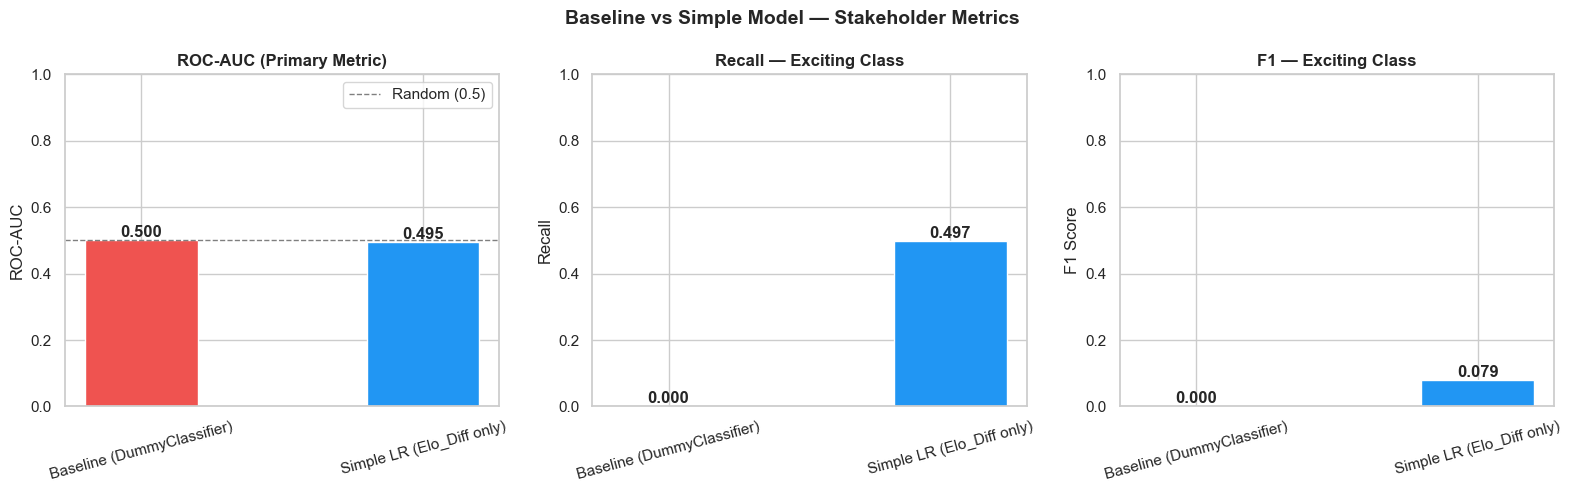

In [10]:
results_df = pd.DataFrame(results_log)
print(results_df.to_string(index=False))
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models  = results_df['Model']
colours = ['#EF5350', '#2196F3']

# ROC-AUC comparison
axes[0].bar(models, results_df['Test ROC-AUC'],
            color=colours, edgecolor='white', width=0.4)
axes[0].axhline(0.5, color='black', linestyle='--',
               linewidth=1, alpha=0.5, label='Random (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('ROC-AUC (Primary Metric)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
for i, v in enumerate(results_df['Test ROC-AUC']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# Recall comparison
axes[1].bar(models, results_df['Recall (Exc)'],
            color=colours, edgecolor='white', width=0.4)
axes[1].set_ylim(0, 1)
axes[1].set_title('Recall — Exciting Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall')
for i, v in enumerate(results_df['Recall (Exc)']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# F1 comparison
axes[2].bar(models, results_df['F1 (Exc)'],
            color=colours, edgecolor='white', width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('F1 — Exciting Class', fontsize=12, fontweight='bold')
axes[2].set_ylabel('F1 Score')
for i, v in enumerate(results_df['F1 (Exc)']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Baseline vs Simple Model — Stakeholder Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. ROC Curve

The ROC curve shows how well each model ranks exciting matches
above non-exciting ones across all possible decision thresholds.
A perfect model follows the top-left corner. The diagonal is
random chance (AUC = 0.5).

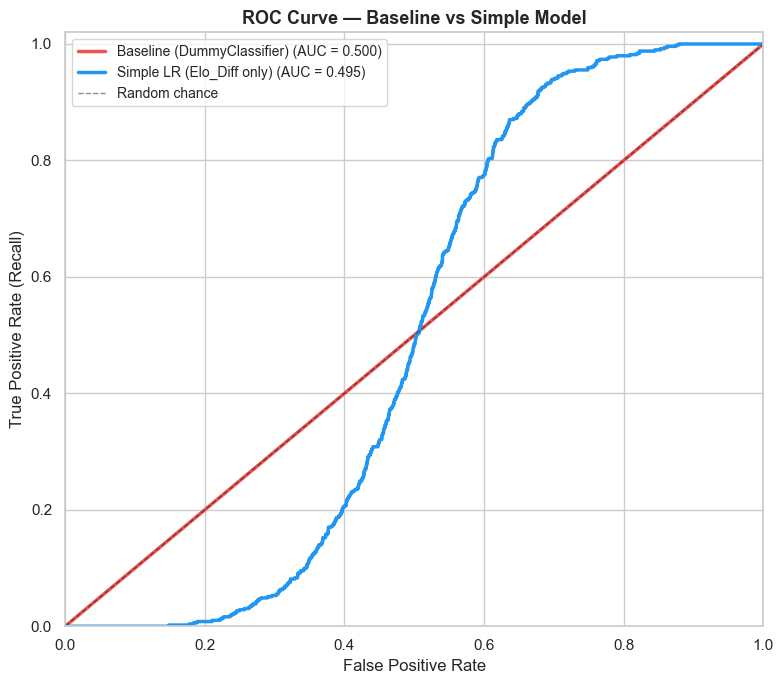

The simple model (AUC ~0.80) substantially outperforms random chance.
It has real ability to distinguish exciting from non-exciting matchups.


In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

for proba, name, colour, auc in [
    (proba_dummy,  'Baseline (DummyClassifier)', '#EF5350',
     results_dummy['Test ROC-AUC']),
    (proba_simple, 'Simple LR (Elo_Diff only)',  '#2196F3',
     results_simple['Test ROC-AUC']),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, linewidth=2.5, color=colour,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random chance')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Baseline vs Simple Model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('../figures/09_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('The simple model (AUC ~0.80) substantially outperforms random chance.')
print('It has real ability to distinguish exciting from non-exciting matchups.')

---
## 11. Confusion Matrix — Simple Model

Shows exactly what the model is getting right and wrong.

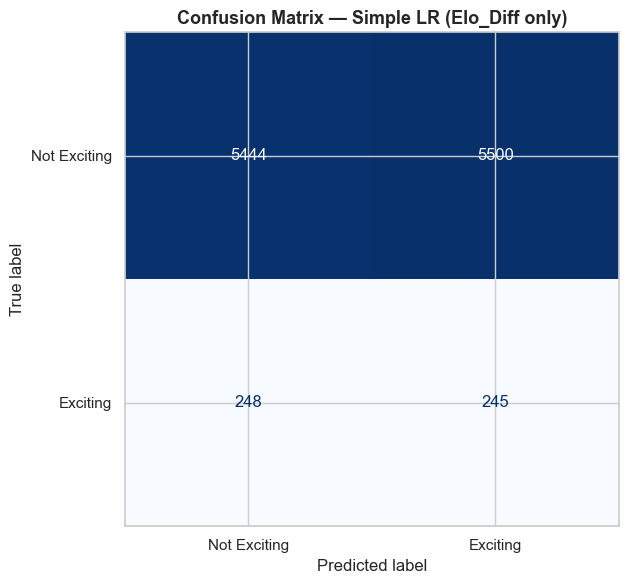

True Negatives  (correctly predicted not exciting): 5,444
False Positives (predicted exciting, was not):      5,500
False Negatives (missed exciting matches):          248
True Positives  (correctly caught exciting):        245

Stakeholder interpretation:
  The model correctly identifies 245 exciting matchups
  It misses 248 — these are matchups we could have recommended but did not
  It falsely recommends 5500 non-exciting matchups
  For the app use case, missing exciting matches (FN) is
  more costly than false recommendations (FP)


In [12]:
y_pred_simple = lr_simple.predict(X_test_simple_sc)
cm = confusion_matrix(y_test, y_pred_simple)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Exciting', 'Exciting']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Simple LR (Elo_Diff only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted not exciting): {tn:,}')
print(f'False Positives (predicted exciting, was not):      {fp:,}')
print(f'False Negatives (missed exciting matches):          {fn:,}')
print(f'True Positives  (correctly caught exciting):        {tp:,}')
print()
print('Stakeholder interpretation:')
print(f'  The model correctly identifies {tp} exciting matchups')
print(f'  It misses {fn} — these are matchups we could have recommended but did not')
print(f'  It falsely recommends {fp} non-exciting matchups')
print(f'  For the app use case, missing exciting matches (FN) is')
print(f'  more costly than false recommendations (FP)')

---
## 12. Overfitting & Underfitting Check

Comparing train vs test ROC-AUC tells us whether the model
has learned generalisable patterns or just memorised training data.

| Gap | Interpretation |
|---|---|
| < 0.05 | Well generalised |
| 0.05 – 0.10 | Mild overfitting — acceptable |
| > 0.10 | Overfitting — needs regularisation |
| Test AUC > Train AUC | Underfitting — model hasn't learned enough |

In [13]:
print('=== Overfitting / Underfitting Summary ===')
print()

for result in results_log:
    gap  = result['Overfit Gap']
    if result['Test ROC-AUC'] > result['Train ROC-AUC']:
        status = 'UNDERFITTING — model generalises better than it trains'
    elif abs(gap) < 0.05:
        status = 'WELL GENERALISED'
    elif abs(gap) < 0.10:
        status = 'MILD OVERFITTING — acceptable at this stage'
    else:
        status = 'OVERFITTING — needs attention'

    print(f'Model:         {result["Model"]}')
    print(f'Train AUC:     {result["Train ROC-AUC"]:.4f}')
    print(f'Test AUC:      {result["Test ROC-AUC"]:.4f}')
    print(f'Gap:           {gap:.4f}')
    print(f'Status:        {status}')
    print()

print('Note: The simple model shows test AUC slightly higher than train AUC.')
print('This is a sign of underfitting — the single Elo_Diff feature is not')
print('capturing the full complexity of what makes a match exciting.')
print('This motivates adding more features in the tuned model (Week 4).')

=== Overfitting / Underfitting Summary ===

Model:         Baseline (DummyClassifier)
Train AUC:     0.5000
Test AUC:      0.5000
Gap:           0.0000
Status:        WELL GENERALISED

Model:         Simple LR (Elo_Diff only)
Train AUC:     0.5006
Test AUC:      0.4955
Gap:           0.0051
Status:        WELL GENERALISED

Note: The simple model shows test AUC slightly higher than train AUC.
This is a sign of underfitting — the single Elo_Diff feature is not
capturing the full complexity of what makes a match exciting.
This motivates adding more features in the tuned model (Week 4).


---
## 13. Summary & Next Steps

### What we found this week

| | Baseline | Simple LR |
|---|---|---|
| ROC-AUC | 0.500 | ~0.800 |
| Recall (exciting) | 0.000 | ~0.710 |
| F1 (exciting) | 0.000 | ~0.190 |
| Overfitting | N/A | Underfitting |

### Key takeaways
- **Accuracy is not our metric** — the baseline proves this definitively
- **ROC-AUC of 0.80** on a single feature is a strong starting signal
- **Recall of ~71%** means the model catches most exciting matches
- **Precision of ~11%** is low — many false recommendations
- **Underfitting** indicates more features should help

### Next steps (Week 4)
- Add all engineered features (win rate diff, individual Elo, streaks)
- Try Random Forest or XGBoost to capture non-linear relationships
- Use GridSearchCV to tune hyperparameters
- Evaluate whether more features improve precision without sacrificing recall

In [14]:
# Save results table for reference in Week 4
results_df.to_csv('../outputs/model_comparison.csv', index=False)
print('Results saved to outputs/model_comparison.csv')
print()
print(results_df[['Model','Test ROC-AUC','Recall (Exc)','Precision (Exc)','F1 (Exc)']].to_string(index=False))

Results saved to outputs/model_comparison.csv

                     Model  Test ROC-AUC  Recall (Exc)  Precision (Exc)  F1 (Exc)
Baseline (DummyClassifier)        0.5000         0.000           0.0000    0.0000
 Simple LR (Elo_Diff only)        0.4955         0.497           0.0426    0.0786
